<a href="https://colab.research.google.com/github/HuongNguyenQuoc/HelloGit/blob/main/06_pytorch_transfer_learning_myself.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from pathlib import Path

data_path = Path("E:\MyProject\Train datasets for myself\GNN\TrainTestGNN\PyTorch_tutorials_video_DanielBrouke")
data_path.mkdir(parents = True, exist_ok = True)
get_video = data_path / "06_pytorch_transfer_learning_video.ipynb"

target = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/video_notebooks/06_pytorch_transfer_learning_video.ipynb")
target.raise_for_status()

with open(get_video, "wb") as f:
    f.write(target.content)



<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_15088/3168699666.py:4: SyntaxWarning: invalid escape sequence '\M'
  data_path = Path("E:\MyProject\Train datasets for myself\GNN\TrainTestGNN\PyTorch_tutorials_video_DanielBrouke")


In [ ]:
import torch
import torchvision
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")


torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
try:
  from torchinfo import summary
except:
  print(f"[INFO] Couldn't find torchinfo... installing it.")
  !pip install -q torchinfo
  from torchinfo import summary

try:
  from going_modular import data_setup, engine
except:
  print(f"[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")


[INFO] Couldn't find going_modular scripts... downloading them from GitHub.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import os
import zipfile
from pathlib import Path
import requests

data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, creating one...")
  image_path.mkdir(parents = True, exist_ok = True)

  #Download pizza, steak, sushi data
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    request.raise_for_status()
    print("Downloading pizza, steak, sushi data...")
    f.write(request.content)

  #Unzip pizza, steak, sushi data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip:
    print("Unzipping pizza, steak, sushi data...")
    zip.extractall(image_path)

  #Remove .zip file
  os.remove(data_path / "pizza_steak_sushi.zip")


data/pizza_steak_sushi directory exists.


In [ ]:
#Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

In [ ]:
# Create a transforms pipeline manually (required for torchvision < 0.13)
manual_transforms = transforms.Compose([
    transforms.Resize(size = (224, 224)), # 1. Reshape all images to 224x224 (though some models may required different size)
    transforms.ToTensor(), #2. Turn image values to between 0 & 1
    transforms.Normalize(mean = [0.485, 0.456, 0.406], #3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                        std = [0.229, 0.224, 0.225] # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
    )
])

In [ ]:
import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = train_dir, test_dir = test_dir,
                                                                               transform = manual_transforms,
                                                                               batch_size = 32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7f77b1f664e0>,
 ['pizza', 'steak', 'sushi'])

In [ ]:
#Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir = train_dir,
                                                                               test_dir = test_dir,
                                                                               transform = auto_transforms,
                                                                               batch_size = 32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7f767eca0ad0>,
 ['pizza', 'steak', 'sushi'])

### 3.2 Setting up a pretrained model

In [ ]:
#OLD: Setup the model with pretrained weights and send it to the target device
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT #.DEFAULT = best available weights
model = torchvision.models.efficientnet_b0(weights = weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
from torchinfo import summary
#Print a summary using torchinfo (uncomment for actual output)
summary(model = model,
        input_size = (1, 3, 224, 244), #Example of [batch_size, color_channels, height, width]
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 244]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 244]     [1, 1280, 7, 8]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 244]     [1, 32, 112, 122]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 244]     [1, 32, 112, 122]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 122]    [1, 32, 112, 122]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 122]    [1, 32, 112, 122]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 122]    [1, 16, 112,

In [ ]:
for param in model.parameters():
  param.requires_grad = False

In [ ]:
len(class_names)

3

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p = 0.2, inplace = True),
    torch.nn.Linear(in_features = 1280,
                    out_features = output_shape,
                    bias = True)
).to(device)

In [ ]:
from torchinfo import summary

summary(model = model,
        input_size = (32, 3, 224, 224),
        verbose = 0,
        col_names = ["input_size",
                "output_size",
                "num_params",
                "trainable"],
        row_settings=["var_names"]
        )

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]         [32, 3]                   --                        Partial
├─Sequential (features)                                      [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]        [32, 32, 112, 112]        --         

### 4. Train model

In [ ]:
#Define loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    params = model.parameters(),
    lr = 0.001
)

In [ ]:
#Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Start the timer
import engine
from engine import train
from timeit import default_timer as timer
start_time = timer()

EPOCHS = 5
res = train(model = model,
            train_dataloader = train_dataloader,
            test_dataloader = test_dataloader,
            optimizer = optimizer,
            loss_fn = loss_fn,
            epochs = EPOCHS,
            device = device)
end_time = timer()
print(f"[INFO] Total time for training: {end_time - start_time:.2f}")
print(f"Results: {res}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.3984 | test_loss: 0.9133 | test_acc: 0.5398
Epoch: 2 | train_loss: 0.8717 | train_acc: 0.7773 | test_loss: 0.7912 | test_acc: 0.8153
Epoch: 3 | train_loss: 0.7648 | train_acc: 0.7930 | test_loss: 0.7464 | test_acc: 0.8561
Epoch: 4 | train_loss: 0.7109 | train_acc: 0.7539 | test_loss: 0.6374 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.6255 | train_acc: 0.7852 | test_loss: 0.6262 | test_acc: 0.8561
[INFO] Total time for training: 12.87
Results: {'train_loss': [1.0924245491623878, 0.8717042207717896, 0.7648178711533546, 0.7109114676713943, 0.6255273520946503], 'train_acc': [0.3984375, 0.77734375, 0.79296875, 0.75390625, 0.78515625], 'test_loss': [0.9132720430692037, 0.7912164131800333, 0.7463682889938354, 0.6373563607533773, 0.6261598467826843], 'test_acc': [0.5397727272727273, 0.8153409090909092, 0.8560606060606061, 0.8655303030303031, 0.8560606060606061]}


In [ ]:
res.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
from typing import Dict
def plot_loss_curves(res: Dict[str, list[float]]):
  train_loss = res["train_loss"]
  test_loss = res["test_loss"]
  train_acc = res["train_acc"]
  test_acc = res["test_acc"]
  epochs = list(range(len(train_loss)))

  plt.figure(figsize = (15, 7))
  plt.subplot(1, 2, 1)
  plt.plot(epochs, train_loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.legend()
  plt.title("Loss")

  plt.subplot(1, 2, 2)
  plt.plot(epochs, train_acc, label = "train_acc")
  plt.plot(epochs, test_acc, label = "test_acc")
  plt.title("Accuracy")
  plt.legend()


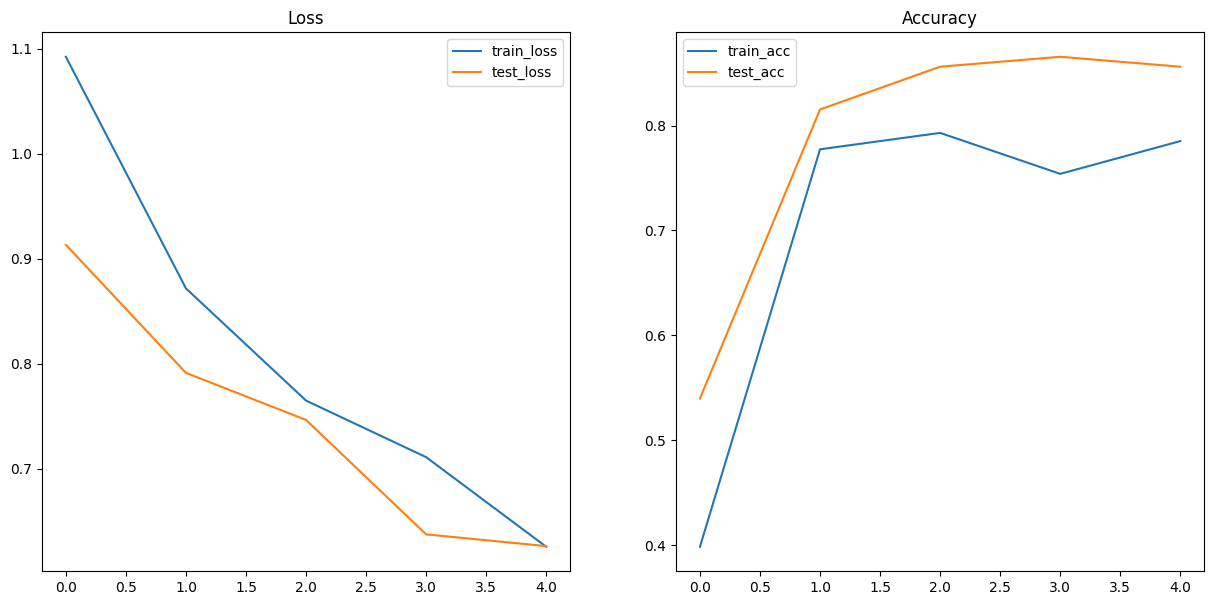

In [ ]:
plot_loss_curves(res = res)